<a href="https://colab.research.google.com/github/sanjyotsawant/CDAC_Training/blob/main/Ass2_PartA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#1
df = pd.read_csv("meridian_daily_sales_raw - meridian_daily_sales_raw.csv.csv")
print(df.shape)
print(df.dtypes)

(1627, 10)
store_id             object
store_name           object
region               object
date                 object
transactions          int64
revenue              object
avg_basket_value    float64
discount_pct         object
footfall              int64
stockout_flag        object
dtype: object


In [ ]:
#Q2
df['store_id'] = df['store_id'].astype(str).str.strip().str.upper()
df['store_name'] = (df['store_name'].astype(str).str.strip().str.title())
df['region'] = (df['region'].astype(str).str.strip().str.title())

print(df[['store_id', 'store_name', 'region']].head())

  store_id       store_name region
0    ST-10  Magnolia Square  South
1    ST-13   Highland Court   West
2    ST-16  Redwood Station   West
3    ST-14    Golden Valley   West
4    ST-04  Silverline Mall  North


In [ ]:
#Q3
df['date'] = pd.to_datetime( df['date'], errors='coerce', dayfirst=True)
print(df['date'].head())
print(df['date'].dtype)

0   2026-03-07
1   2026-05-27
2   2026-05-24
3   2026-04-20
4   2026-03-04
Name: date, dtype: datetime64[ns]
datetime64[ns]


In [ ]:
#Q4
missing_values = df.isna().sum()

print("Missing values per column:")
print(missing_values)
df["revenue"] = (
    df["revenue"]
    .astype(str)
    .str.replace(r"[$,\s]", "", regex=True)
)

# Convert blanks/text entries to NaN, then convert the whole column to numeric
df["revenue"] = pd.to_numeric(df["revenue"], errors="coerce")

print("Revenue dtype:", df["revenue"].dtype)
print("Missing revenue values:", df["revenue"].isnull().sum())

Missing values per column:
store_id             0
store_name           0
region               0
date                 0
transactions         0
revenue             53
avg_basket_value     0
discount_pct         0
footfall             0
stockout_flag        0
dtype: int64
Revenue dtype: float64
Missing revenue values: 226


In [ ]:
#Q5
df['stockout_flag'] = (
    df['stockout_flag']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": True, "no": False, "true": True, "false": False, "1": True, "0": False})
    .astype("boolean")
)

print(df['stockout_flag'].value_counts(dropna=False))
print(df['stockout_flag'].dtype)

stockout_flag
<NA>     803
False    496
True     328
Name: count, dtype: Int64
boolean


In [ ]:
#Q6
before = len(df)
print("before: ", before)

duplicates = df[
    (df["store_id"].str.strip().str.upper() == "ST-11") &
    df.duplicated(keep=False)
]
# print(duplicates)
df = df.drop_duplicates(keep="first")
after = len(df)
print("after: ", after)


before:  1620
after:  1620


In [ ]:
#Q7
df["data_entry_error"] = (df["transactions"] < 0) | (~pd.to_numeric(df["discount_pct"], errors="coerce").between(0, 100))
print(df["data_entry_error"])

0       False
1       False
2       False
3       False
4        True
        ...  
1622    False
1623    False
1624    False
1625    False
1626    False
Name: data_entry_error, Length: 1620, dtype: bool


In [ ]:
#Q8
df.to_csv("meridian_daily_sales_cleaned.csv", index=False)
print("Final row count:", len(df))

Final row count: 1620


In [ ]:
#Q9
summary = df.groupby("store_id")["revenue"].quantile([0.25, 0.50, 0.75]).unstack()
summary.columns = ["Q1", "Q2", "Q3"]
summary["IQR"] = summary["Q3"] - summary["Q1"]

print(summary)

store = summary.index[0]
values = sorted(df.loc[df["store_id"] == store, "revenue"].dropna().tolist())

print("name of the store ", store)
print("values ", values)
print(summary.loc[store])

                 Q1        Q2          Q3        IQR
store_id                                            
ST-01     4001.6225  5283.300   6801.4800  2799.8575
ST-02     4189.7600  5949.760   8447.7500  4257.9900
ST-03     4715.3800  6262.740   7912.5100  3197.1300
ST-04     2736.7700  3269.460   4389.2800  1652.5100
ST-05     3272.6225  4343.025   5567.3975  2294.7750
ST-06     3518.1375  4919.270   6368.7375  2850.6000
ST-07     5375.0275  7069.995   9799.8950  4424.8675
ST-08     2812.2650  3577.775   4905.5100  2093.2450
ST-09     5094.7500  6358.590   8092.0200  2997.2700
ST-10     3240.2000  4528.030   5559.3250  2319.1250
ST-11     4447.5525  5990.765   8250.1925  3802.6400
ST-12     5807.6100  8200.530  10979.5600  5171.9500
ST-13     3675.9750  4927.040   5956.5150  2280.5400
ST-14     3796.6400  5410.490   7310.8900  3514.2500
ST-15     2626.9600  3360.730   4212.8400  1585.8800
ST-16     3973.7325  5386.160   7623.7075  3649.9750
ST-17     3991.4900  5182.570   6940.7800  294

In [ ]:
#Q10
fences = summary.copy()
fences["lower_fence"] = fences["Q1"] - 1.5 * fences["IQR"]
fences["upper_fence"] = fences["Q3"] + 1.5 * fences["IQR"]

print(fences[["lower_fence", "upper_fence"]])

          lower_fence  upper_fence
store_id                          
ST-01      -198.16375  11001.26625
ST-02     -2197.22500  14834.73500
ST-03       -80.31500  12708.20500
ST-04       258.00500   6868.04500
ST-05      -169.54000   9009.56000
ST-06      -757.76250  10644.63750
ST-07     -1262.27375  16437.19625
ST-08      -327.60250   8045.37750
ST-09       598.84500  12587.92500
ST-10      -238.48750   9038.01250
ST-11     -1256.40750  13954.15250
ST-12     -1950.31500  18737.48500
ST-13       255.16500   9377.32500
ST-14     -1474.73500  12582.26500
ST-15       248.14000   6591.66000
ST-16     -1501.23000  13098.67000
ST-17      -432.44500  11364.71500
ST-18       173.21750   5531.99750


In [ ]:
#Q11
df["outlier"] = (
    (df["revenue"] < df["store_id"].map(fences["lower_fence"])) |
    (df["revenue"] > df["store_id"].map(fences["upper_fence"]))
)

outliers = df[df["outlier"]]

print("Number of outliers:", len(outliers))
print(outliers[["store_id", "date"]])


Number of outliers: 42
     store_id       date
23      ST-09 2026-04-14
33      ST-08 2026-04-20
46      ST-11 2026-05-18
55      ST-09 2026-05-27
91      ST-05 2026-05-09
101     ST-07 2026-05-02
135     ST-08 2026-04-12
136     ST-05 2026-05-07
137     ST-03 2026-05-19
149     ST-07 2026-05-29
207     ST-17 2026-04-01
236     ST-03 2026-04-02
239     ST-09 2026-05-26
297     ST-04 2026-04-24
301     ST-16 2026-04-08
361     ST-17 2026-04-17
370     ST-06 2026-05-16
433     ST-18 2026-04-15
456     ST-03 2026-04-11
517     ST-13 2026-04-14
541     ST-10 2026-03-02
563     ST-04 2026-03-22
591     ST-09 2026-04-06
632     ST-10 2026-11-03
666     ST-06 2026-05-21
732     ST-07 2026-04-09
807     ST-06 2026-03-16
829     ST-18 2026-04-26
881     ST-10 2026-03-15
895     ST-13 2026-05-21
910     ST-15 2026-05-13
978     ST-09 2026-03-04
1028    ST-01 2026-05-19
1040    ST-04 2026-05-17
1053    ST-18 2026-04-12
1087    ST-10 2026-04-10
1108    ST-17 2026-03-28
1214    ST-09 2026-04-23
13

In [ ]:
#Q12
footfall_summary = df.groupby("store_id")["footfall"].quantile([0.25, 0.50, 0.75]).unstack()
footfall_summary.columns = ["Q1", "Q2", "Q3"]
footfall_summary["IQR"] = footfall_summary["Q3"] - footfall_summary["Q1"]

footfall_summary["lower_fence"] = footfall_summary["Q1"] - 1.5 * footfall_summary["IQR"]
footfall_summary["upper_fence"] = footfall_summary["Q3"] + 1.5 * footfall_summary["IQR"]

df["footfall_outlier"] = (
    (df["footfall"] < df["store_id"].map(footfall_summary["lower_fence"])) |
    (df["footfall"] > df["store_id"].map(footfall_summary["upper_fence"]))
)

# fences
print("Footfall fences:")
print(footfall_summary[["lower_fence", "upper_fence"]])

print("\nNumber of footfall outliers:", df["footfall_outlier"].sum())

sensor_fault = df["footfall"].eq(40000)
print("~40,000 sensor-fault days:", sensor_fault.sum())
print("~40,000 days caught by fence:", (sensor_fault & df["footfall_outlier"]).sum())

Footfall fences:
          lower_fence  upper_fence
store_id                          
ST-01         160.125     1017.125
ST-02         194.625      995.625
ST-03         214.750      962.750
ST-04         220.000     1020.000
ST-05         213.625      930.625
ST-06         176.500     1010.500
ST-07         204.250     1000.250
ST-08         126.500     1060.500
ST-09         249.000      935.000
ST-10         231.875      994.875
ST-11         228.250      998.250
ST-12         167.125     1050.125
ST-13         203.000     1035.000
ST-14         150.125     1017.125
ST-15         211.125     1012.125
ST-16         210.875      969.875
ST-17         129.750     1035.750
ST-18         182.250     1016.250

Number of footfall outliers: 13
~40,000 sensor-fault days: 0
~40,000 days caught by fence: 0


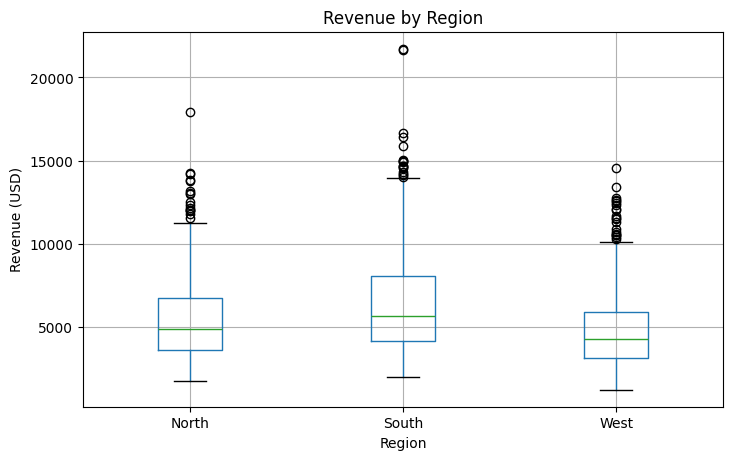

              Q1        Q3       IQR
region                              
North   3626.300  6752.100  3125.800
South   4144.105  8077.815  3933.710
West    3123.590  5938.855  2815.265
Region with widest IQR: South


In [ ]:
#Q13
df.boxplot( column='revenue', by='region', figsize=(8, 5))

plt.title('Revenue by Region')
plt.suptitle('')
plt.xlabel('Region')
plt.ylabel('Revenue (USD)')

plt.show()

regional_iqr = ( df.groupby('region')['revenue']
    .agg(
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75) ))

regional_iqr['IQR'] = ( regional_iqr['Q3'] - regional_iqr['Q1'])
print(regional_iqr)

widest_region = regional_iqr['IQR'].idxmax()
print("Region with widest IQR:", widest_region)

In [ ]:
#Q14
store_stats = (
    df.groupby('store_id')['revenue'].agg( median='median', mean='mean', max='max'))

print(store_stats.sort_values('median',ascending=False))
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)

IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
revenue_outliers = df[
    (df['revenue'] < lower_fence) |
    (df['revenue'] > upper_fence)
].copy()
store_outlier_counts = (
    revenue_outliers
    .groupby('store_id').size() )

print(store_outlier_counts)

st13 = df[df['store_id'] == 'ST-13']

print(
    "ST-13 median:",
    st13['revenue'].median()
)

print(
    "ST-13 maximum:",
    st13['revenue'].max()
)

print(
    "ST-13 outliers:",
    len(
        st13[
            (st13['revenue'] < lower_fence) |
            (st13['revenue'] > upper_fence)
        ]
    )
)

            median         mean       max
store_id                                 
ST-12     8200.530  8719.938961  15876.48
ST-07     7069.995  8022.933421  21721.54
ST-09     6358.590  7110.316316  15033.05
ST-03     6262.740  6633.822469  14250.38
ST-11     5990.765  6646.579324  14158.45
ST-02     5949.760  6484.997922  13800.45
ST-14     5410.490  5889.539577  12576.42
ST-16     5386.160  6144.946447  14537.77
ST-01     5283.300  5721.058625  12183.51
ST-17     5182.570  5868.202857  13412.55
ST-13     4927.040  5119.790800  10539.98
ST-06     4919.270  5522.393293  17917.70
ST-10     4528.030  4778.220714  11228.01
ST-05     4343.025  4622.715513   9365.37
ST-08     3577.775  4104.671875   9965.37
ST-15     3360.730  3520.305443   7682.72
ST-04     3269.460  3774.841333  10746.48
ST-18     2781.845  2985.211447   7407.38
store_id
ST-01     1
ST-02     6
ST-03     4
ST-06     3
ST-07     9
ST-09     8
ST-11     5
ST-12    15
ST-14     1
ST-16     5
ST-17     3
dtype: int64
ST-13 

In [ ]:
#Q15
sensor_fault_mask = df['footfall'] > 10000

print(
    "Sensor fault rows:",
    sensor_fault_mask.sum()
)
original_Q1 = df['footfall'].quantile(0.25)
original_Q3 = df['footfall'].quantile(0.75)

original_IQR = original_Q3 - original_Q1

original_lower = (
    original_Q1 -
    1.5 * original_IQR
)

original_upper = (
    original_Q3 +
    1.5 * original_IQR
)
footfall_clean = df.loc[
    ~sensor_fault_mask,
    'footfall'
]
new_Q1 = footfall_clean.quantile(0.25)
new_Q3 = footfall_clean.quantile(0.75)

new_IQR = new_Q3 - new_Q1

new_lower = new_Q1 - 1.5 * new_IQR
new_upper = new_Q3 + 1.5 * new_IQR
print("Original lower fence:", original_lower)
print("New lower fence:", new_lower)

print("Original upper fence:", original_upper)
print("New upper fence:", new_upper)

print(
    "Lower fence shift:",
    new_lower - original_lower
)

print(
    "Upper fence shift:",
    new_upper - original_upper
)

Sensor fault rows: 3
Original lower fence: 189.0
New lower fence: 187.5
Original upper fence: 1007.0
New upper fence: 1007.5
Lower fence shift: -1.5
Upper fence shift: 0.5


In [ ]:
#Q16
print("Revenue Q1:", Q1)
print("Revenue Q3:", Q3)
print("Revenue IQR:", IQR)
print("Upper fence:", upper_fence)

print(
    "Number of revenue outliers:",
    len(revenue_outliers)
)

print("\nOutliers by store:")
print(
    revenue_outliers['store_id']
    .value_counts()
)

Revenue Q1: 3581.81
Revenue Q3: 6921.705
Revenue IQR: 3339.895
Upper fence: 11931.5475
Number of revenue outliers: 60

Outliers by store:
store_id
ST-12    15
ST-07     9
ST-09     8
ST-02     6
ST-11     5
ST-16     5
ST-03     4
ST-17     3
ST-06     3
ST-14     1
ST-01     1
Name: count, dtype: int64


In [ ]:
#Q17
revenue = df['revenue'].dropna()

mean_revenue = revenue.mean()
median_revenue = revenue.median()

mode_revenue = revenue.mode()

print("Mean:", mean_revenue)
print("Median:", median_revenue)
print("Mode:")
print(mode_revenue)
print("\nMean > Median:",
      mean_revenue > median_revenue)

Mean: 5638.474261119082
Median: 4938.465
Mode:
0    4175.45
1    5344.68
Name: revenue, dtype: float64

Mean > Median: True


In [ ]:
#Q18
revenue_skewness = df['revenue'].skew()

print(
    "Revenue skewness:",
    revenue_skewness
)
if revenue_skewness > 1:
    print("Strong right skew")
elif revenue_skewness > 0.5:
    print("Moderate right skew")
elif revenue_skewness > 0:
    print("Mild right skew")
elif revenue_skewness < -1:
    print("Strong left skew")
elif revenue_skewness < -0.5:
    print("Moderate left skew")
else:
    print("Approximately symmetric")

Revenue skewness: 1.3651310698421475
Strong right skew


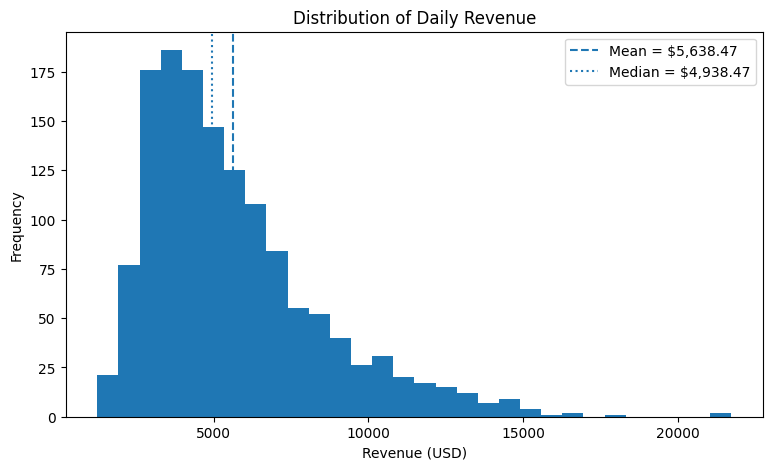

In [ ]:
#Q19
revenue = df['revenue'].dropna()

mean_revenue = revenue.mean()
median_revenue = revenue.median()

plt.figure(figsize=(9, 5))

plt.hist(
    revenue,
    bins=30
)

plt.axvline(
    mean_revenue,
    linestyle='--',
    label=f'Mean = ${mean_revenue:,.2f}'
)

plt.axvline(
    median_revenue,
    linestyle=':',
    label=f'Median = ${median_revenue:,.2f}'
)

plt.xlabel('Revenue (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Revenue')

plt.legend()

plt.show()

In [ ]:
#Q20
print("Mean:", df['revenue'].mean())
print("Median:", df['revenue'].median())
print("Skewness:", df['revenue'].skew())

Mean: 5638.474261119082
Median: 4938.465
Skewness: 1.3651310698421475


In [ ]:
#Q21
footfall_skew_before = df['footfall'].skew()

print(
    "Footfall skewness before:",
    footfall_skew_before
)
footfall_without_faults = df.loc[
    df['footfall'] <= 10000,
    'footfall'
]
footfall_skew_after = (
    footfall_without_faults.skew()
)

print(
    "Footfall skewness after:",
    footfall_skew_after
)
skew_change = (
    footfall_skew_after -
    footfall_skew_before
)

print(
    "Change in skewness:",
    skew_change
)

Footfall skewness before: 22.956568189705976
Footfall skewness after: 0.025380413025283873
Change in skewness: -22.93118777668069


In [ ]:
#Q22
mean_revenue = df['revenue'].mean()
median_revenue = df['revenue'].median()
max_revenue = df['revenue'].max()

print("Median:", median_revenue)
print("Mean:", mean_revenue)
print("Maximum:", max_revenue)

Median: 4938.465
Mean: 5638.474261119082
Maximum: 21721.54


In [ ]:
#Q23
def regional_statistics(group):

    Q1 = group['revenue'].quantile(0.25)
    Q3 = group['revenue'].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = (
        (group['revenue'] < lower) |
        (group['revenue'] > upper)
    ).sum()

    return pd.Series({
        'Median Revenue': group['revenue'].median(),
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Outlier Count': outlier_count
    })


regional_summary = (
    df.groupby('region')
    .apply(regional_statistics)
)

print(regional_summary)

        Median Revenue        Q1        Q3       IQR  Outlier Count
region                                                             
North          4890.38  3626.300  6752.100  3125.800           16.0
South          5668.36  4144.105  8077.815  3933.710           17.0
West           4275.05  3123.590  5938.855  2815.265           20.0


/tmp/ipykernel_2780/2162030739.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(regional_statistics)


In [ ]:
#Q24
regional_summary = (
    df.groupby('region')
    .apply(regional_statistics)
)

print(regional_summary)
print(
    regional_summary
    .sort_values(
        'IQR',
        ascending=False
    )
)
print(
    regional_summary
    .sort_values(
        'Outlier Count',
        ascending=False
    )
)
south = regional_summary.loc['South']

print("South median:",
      south['Median Revenue'])

print("South IQR:",
      south['IQR'])

print("South outliers:",
      south['Outlier Count'])

        Median Revenue        Q1        Q3       IQR  Outlier Count
region                                                             
North          4890.38  3626.300  6752.100  3125.800           16.0
South          5668.36  4144.105  8077.815  3933.710           17.0
West           4275.05  3123.590  5938.855  2815.265           20.0
        Median Revenue        Q1        Q3       IQR  Outlier Count
region                                                             
South          5668.36  4144.105  8077.815  3933.710           17.0
North          4890.38  3626.300  6752.100  3125.800           16.0
West           4275.05  3123.590  5938.855  2815.265           20.0
        Median Revenue        Q1        Q3       IQR  Outlier Count
region                                                             
West           4275.05  3123.590  5938.855  2815.265           20.0
South          5668.36  4144.105  8077.815  3933.710           17.0
North          4890.38  3626.300  6752.100  3125

/tmp/ipykernel_2780/2199200067.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(regional_statistics)


In [ ]:
#Q25
print("========== EXECUTIVE SUMMARY ==========")

print(
    "Final rows:",
    len(df)
)

print(
    "Revenue median:",
    round(df['revenue'].median(), 2)
)

print(
    "Revenue mean:",
    round(df['revenue'].mean(), 2)
)

print(
    "Revenue skewness:",
    round(df['revenue'].skew(), 3)
)

print(
    "Revenue Q1:",
    round(df['revenue'].quantile(0.25), 2)
)

print(
    "Revenue Q3:",
    round(df['revenue'].quantile(0.75), 2)
)

print(
    "Revenue IQR:",
    round(
        df['revenue'].quantile(0.75)
        -
        df['revenue'].quantile(0.25),
        2
    )
)

print(
    "Revenue outliers:",
    len(revenue_outliers)
)

print(
    "Footfall skew before:",
    round(
        df['footfall'].skew(),
        3
    )
)

print(
    "Footfall skew after:",
    round(
        footfall_without_faults.skew(),
        3
    )
)

print("\nRegional summary:")
print(regional_summary)

========== EXECUTIVE SUMMARY ==========
Final rows: 1620
Revenue median: 4938.47
Revenue mean: 5638.47
Revenue skewness: 1.365
Revenue Q1: 3581.81
Revenue Q3: 6921.7
Revenue IQR: 3339.9
Revenue outliers: 60
Footfall skew before: 22.957
Footfall skew after: 0.025

Regional summary:
        Median Revenue        Q1        Q3       IQR  Outlier Count
region                                                             
North          4890.38  3626.300  6752.100  3125.800           16.0
South          5668.36  4144.105  8077.815  3933.710           17.0
West           4275.05  3123.590  5938.855  2815.265           20.0
